In [1]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *
from scipy.interpolate import RectBivariateSpline

In [2]:
np.sqrt(137.)*6.93e-11*3/(4*np.pi)**2 * (5e4)**2 * 2

np.float64(0.07704865275457566)

In [3]:
from scipy import constants as const
(const.hbar * const.c / const.e)

1.973269804593025e-07

In [4]:
nu0 = 30.
L = const.c/(nu0*1e9)
print( L/(const.hbar * const.c / const.e) )
print( (1/(nu0*1e9*const.hbar/const.e)) )
print(1e9*const.hbar/const.e)

50642.248262620866
50642.248262620866
6.582119569509066e-07


In [5]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [6]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 1000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data()
# --- temperature transfer function ---
ells, ks, T_lk = transfer.get_transfer(source=0)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [7]:
nB = -1

In [8]:
norm = local.normalization(n=-nB)

In [9]:
r_grid = np.logspace(2,5,50)

In [10]:
Xi = local.Xi(lmax, r_grid, eta0, nB, kn=100, lnkmin=-6, lnkmax=0, check_claa=True)

In [11]:
Xi = local.claa(lmax, eta0, nB, xn=100, lnxmin=-6, lnxmax=4)

In [12]:
l_list = range(2, lmax)
claa = np.zeros((lmax+1))
for ell in l_list:
    l = int(ell)
    claa[l] = Xi[(l,'aa')]

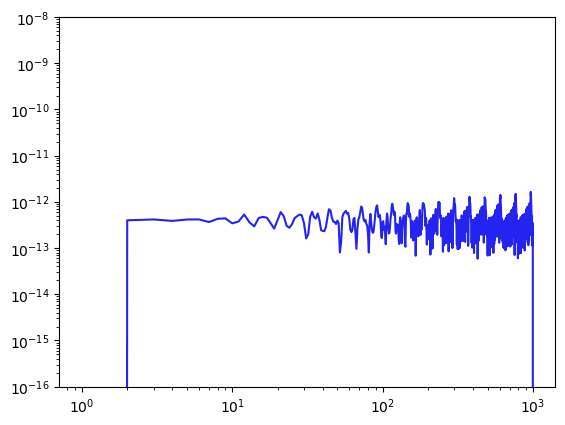

In [13]:
ylim(1e-16,1e-8)
l = np.linspace(0,lmax,lmax+1)
loglog(l,claa*norm['aa'])